In [95]:
import pandas as pd 
import numpy as np
df = pd.DataFrame({
    'age': [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 50]
})

In [96]:
# generate non-normal data (exponential Distribution)
from matplotlib.pylab import size


from matplotlib import scale


np.random.seed(0)
df = np.random.exponential(size=1000, scale=2)
df = pd.DataFrame(df, columns=['values'])
df.head()

,values
0,1.591749
1,2.511862
2,1.846446
3,1.574402
4,1.102097


In [97]:
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import QuantileTransformer
pt_boxcox = PowerTransformer(method='box-cox')
pt_yeo = PowerTransformer(method='yeo-johnson')
qt = QuantileTransformer(output_distribution='normal')
df['boxcox'] = pt_boxcox.fit_transform(df[['values']]+1)
df['yeo-johnson'] = pt_yeo.fit_transform(df[['values']]).ravel()
df['quantile'] = qt.fit_transform(df[['values']])

In [98]:
df.head()

,values,boxcox,yeo-johnson,quantile
0,1.591749,0.179335,0.179335,0.162552
1,2.511862,0.677330,0.677331,0.587964
2,1.846446,0.339698,0.339698,0.286135
3,1.574402,0.167607,0.167607,0.157469
4,1.102097,-0.202107,-0.202107,-0.154930


In [99]:
from sklearn.preprocessing import Normalizer
data = [[1,1,1], [1,1,0], [1,0,0]]
norm = Normalizer(norm='l1')
qnorm = norm.fit_transform(data)
qnorm

array([[0.33333333, 0.33333333, 0.33333333],
       [0.5       , 0.5       , 0.        ],
       [1.        , 0.        , 0.        ]])

In [100]:
import pandas as pd
import numpy as np
# example dataset with skewed values
df = { "values": [1,5,10,20,50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000,100000]}
df = pd.DataFrame(df)
df.head()

,values
0,1
1,5
2,10
3,20
4,50


In [101]:
df['log_values'] = np.log(df['values'])
df.sample

<bound method NDFrame.sample of     values  log_values
0        1    0.000000
1        5    1.609438
2       10    2.302585
3       20    2.995732
4       50    3.912023
5      100    4.605170
6      200    5.298317
7      500    6.214608
8     1000    6.907755
9     2000    7.600902
10    5000    8.517193
11   10000    9.210340
12   20000    9.903488
13   50000   10.819778
14  100000   11.512925>

In [102]:
# import seaborn as sns

# for col in df.columns:
#     import matplotlib.pyplot as plt

#     for col in df.columns:
#         sns.histplot(df[col], kde=True)
#         plt.show()
#     plt.show()


In [103]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [104]:
df = sns.load_dataset('titanic')
x = df[['pclass', 'sex', 'age', 'fare']]
y = df['survived']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
numeric_features = ['age', 'fare']
categorical_features = ['pclass', 'sex', 'embarked']
scalar= StandardScaler()
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', scalar)
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])
x = df[['pclass', 'sex', 'age', 'fare', 'embarked']]
y = df['survived']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')


Accuracy: 0.78


In [105]:
df= sns.load_dataset('tips')

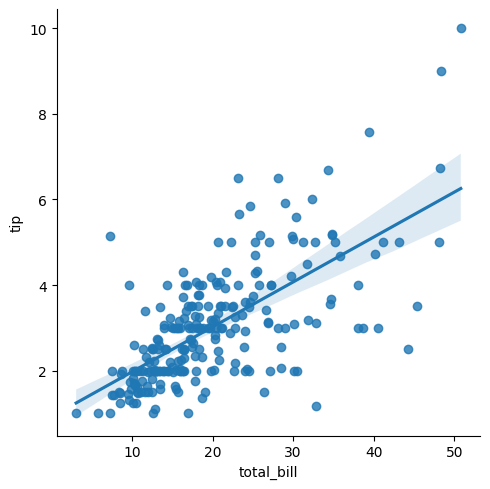

In [106]:
sns.lmplot(x = 'total_bill', y = 'tip', data=df)

In [107]:
standard = StandardScaler()
df[['total_bill','tip']]= standard.fit_transform(df[['total_bill', 'tip']])
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,-0.314711,-1.439947,Female,No,Sun,Dinner,2
1,-1.063235,-0.969205,Male,No,Sun,Dinner,3
2,0.137780,0.363356,Male,No,Sun,Dinner,3
3,0.438315,0.225754,Male,No,Sun,Dinner,2
4,0.540745,0.443020,Female,No,Sun,Dinner,4


In [108]:
# sns.lmplot(x = 'total_bill', y = 'tip', data=df)

In [109]:
x = df[['total_bill']]
y = df[['tip']]

In [110]:
X_train, X_test, Y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [111]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [112]:
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [113]:
model.predict([[15]])

array([[10.35454829]])

In [114]:
# evaluation the model
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
y_pred = model.predict(X_test)
print('MSE: ', mean_squared_error(y_test, y_pred))
print('R2: ', r2_score(y_test, y_pred))
print('R2: ', r2_score (y_test, y_pred))
print('MAE: ', mean_absolute_error(y_test, y_pred))
print('MAPE: ', mean_absolute_percentage_error(y_test, y_pred))

MSE:  0.2983382530785567
R2:  0.5449381659234667
R2:  0.5449381659234667
MAE:  0.4496364577054319
MAPE:  7.369211703304975


In [115]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

In [116]:
df = sns.load_dataset('tips')
x = df[[ 'total_bill', 'size', 'day']]
y = df['tip']
numeric_features = ['total_bill', 'size']
categorical_features = ['day']
transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])
X_train, X_test, Y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
pipeline = Pipeline(steps=[
    ('preprocessor', transformer),
    ('model', LinearRegression())
])
pipeline.fit(X_train, Y_train)
y_pred = pipeline.predict(X_test)
print('MSE: ', mean_squared_error(y_test, y_pred))
print('R2: ', r2_score(y_test, y_pred))
print('MAE: ', mean_absolute_error(y_test, y_pred))
print('MAPE: ', mean_absolute_percentage_error(y_test, y_pred))


MSE:  0.6655725405795047
R2:  0.46752976130485213
MAE:  0.6591957722968487
MAPE:  0.2730622135259165


In [117]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
df = sns.load_dataset('diamonds')
x = df.drop('price', axis=1)
y = df['price']
numeric_features= df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z']]
categorical_features = df[['cut', 'color', 'clarity']]
# processor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), numeric_features),
#         ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
#     ]
# )
# X_train, X_test, Y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# pipeline = Pipeline(steps=[
#     ('preprocessor', processor),
#     # ('model', LinearRegression())
#     ('model', DecisionTreeRegressor(random_state=42))
# ])
# Fix column specification: ColumnTransformer expects column names (list), not DataFrames
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z']
categorical_features = ['cut', 'color', 'clarity']

processor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
X_train, X_test, Y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
pipeline = Pipeline(steps=[
    ('preprocessor', processor),
    # ('model', LinearRegression())
    ('model', DecisionTreeRegressor(random_state=42))
])

pipeline.fit(X_train, Y_train)
y_pred = pipeline.predict(X_test)
print('MSE: ', mean_squared_error(y_test, y_pred))
print('R2: ', r2_score(y_test, y_pred))
print('MAE: ', mean_absolute_error(y_test, y_pred))
print('MAPE: ', mean_absolute_percentage_error(y_test, y_pred))

MSE:  555391.1449758991
R2:  0.9650627550495705
MAE:  360.1981831664813
MAPE:  0.08652095133694603


MSE:  11.918073751622314
R2:  0.9554314660552853
MAE:  2.634106551875724
MAPE:  0.4485698687312857


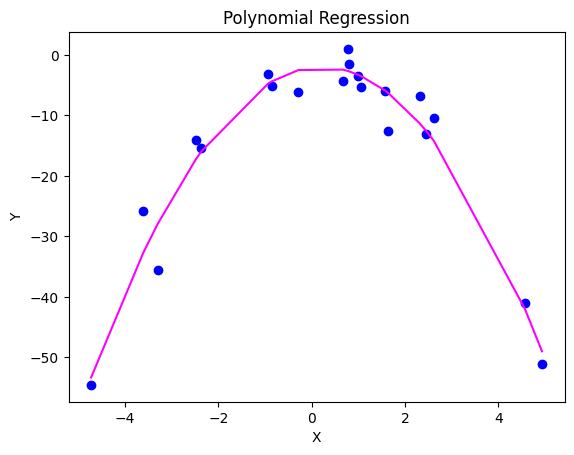

In [124]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import operator
# Step 1: Create Dummy Data
np.random.seed(0)
x = 2 - 3* np.random.normal(0, 1, 20)
y = x - 2* (x ** 2) + np.random.normal(-3, 3, 20)
# Step 2: Transform the features to polynomial features
degree = 2 # Degree of the polynomial
poly_features= PolynomialFeatures (degree)
x_poly = poly_features.fit_transform(x.reshape(-1, 1))
# Step 3: Train Linear Regression Model
model=LinearRegression()
model.fit(x_poly, y)
y_poly_pred = model.predict(x_poly)
#evaluation the model
print('MSE: ', mean_squared_error(y, y_poly_pred))
print('R2: ', r2_score(y, y_poly_pred))
print('MAE: ', mean_absolute_error(y, y_poly_pred))
print('MAPE: ', mean_absolute_percentage_error(y, y_poly_pred))
# Step 4: Plotting the results
plt.scatter(x, y, color='blue')
sorted_axis = operator.itemgetter(0)
sorted_zip = sorted(zip(x, y, y_poly_pred), key=sorted_axis)
x, y, y_poly_pred = zip(*sorted_zip)
plt.plot(x, y_poly_pred, color='magenta')
plt.title('Polynomial Regression')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [125]:
from sklearn.linear_model import Ridge
import numpy as np
x = np.array([[1,1], [1,2], [2,2], [2,3]])
y = np.dot(x, np.array([1, 2])) + 3
model = Ridge(alpha=1.0)
model.fit(x, y)
print(model.coef_)
print(model.intercept_)

[0.8 1.4]
4.5


In [126]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
df = sns.load_dataset('diamonds')

In [130]:
x = df.drop(columns=['price'])
y = df['price']
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z']
categorical_features = ['cut', 'color', 'clarity']
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])
X_train, X_test, Y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=0.5))
])

In [131]:
lr_pipeline.fit(X_train, Y_train)
lr_pred = lr_pipeline.predict(X_test)
print('Linear Regression:')
print('MSE: ', mean_squared_error(y_test, lr_pred))
print('R2: ', r2_score(y_test, lr_pred))
print('MAE: ', mean_absolute_error(y_test, lr_pred))
print('MAPE: ', mean_absolute_percentage_error(y_test, lr_pred))
ridge_pipeline.fit(X_train, Y_train)
ridge_pred = ridge_pipeline.predict(X_test)
print('Ridge Regression:')
print('MSE: ', mean_squared_error(y_test, ridge_pred))
print('R2: ', r2_score(y_test, ridge_pred))
print('MAE: ', mean_absolute_error(y_test, ridge_pred))
print('MAPE: ', mean_absolute_percentage_error(y_test, ridge_pred))


Linear Regression:
MSE:  1288705.477851676
R2:  0.9189331350419386
MAE:  737.1513665933284
MAPE:  0.3952933516494359
Ridge Regression:
MSE:  1288691.2489788434
R2:  0.9189340301185347
MAE:  737.145505679202
MAPE:  0.3952510372855168


In [141]:
from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
X, y = make_regression(n_samples=100, n_features=20, noise=0.1, random_state=42)
model = Lasso(alpha=0.1)
ridge_model = Ridge(alpha=0.1)
model.fit(X, y)
lasso_pred = model.predict(X)
ridge_pred = ridge_model.fit(X, y).predict(X)
print('Lasso Regression:')
print('MSE: ', mean_squared_error(y, lasso_pred))
print('Ridge Regression:')
print ('MSE: ', mean_squared_error(y, ridge_pred))

Lasso Regression:
MSE:  0.12138999318863583
Ridge Regression:
MSE:  0.047188319348096176


In [145]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso, Ridge
import numpy as np
# Create a Lasso regression object
lasso = Lasso()
# Create a dictionary for the grid search key and values
param_grid = {'alpha': np.arange(1, 10, 0.1)}
# Use grid search to find the best value for alpha
lasso_cv=GridSearchCV(lasso, param_grid, cv=10)
# Fit the model
lasso_cv.fit(X, y)
# Print the tuned parameters and score
print("Tuned Lasso Regression Parameters: {}".format(lasso_cv.best_params_))
print("Best score is {}".format(lasso_cv.best_score_))

Tuned Lasso Regression Parameters: {'alpha': np.float64(1.0)}
Best score is 0.9993518846001157


In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler

In [148]:
df = sns.load_dataset('titanic')

In [154]:
df.drop('deck', axis=1, inplace=True, errors='ignore')
df['age'].fillna(df['age'].median(), inplace=True)
df['fare'].fillna(df['fare'].median(), inplace=True)
df['embark_town'].fillna(df['embark_town'].mode()[0], inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype == 'category':
        df[col] = LabelEncoder().fit_transform(df[col])

In [168]:
X = df.drop('survived', axis=1)
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Accuracy: ', accuracy_score(y_test, y_pred))
print('recall_score: ', recall_score(y_test, y_pred))
print('precision_score: ', precision_score(y_test, y_pred))
print('f1_score: ', f1_score(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('classification_report:\n', classification_report(y_test, y_pred))

Accuracy:  1.0
recall_score:  1.0
precision_score:  1.0
f1_score:  1.0
Confusion Matrix:
 [[105   0]
 [  0  74]]
classification_report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        74

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



Text(70.72222222222221, 0.5, 'Actual')

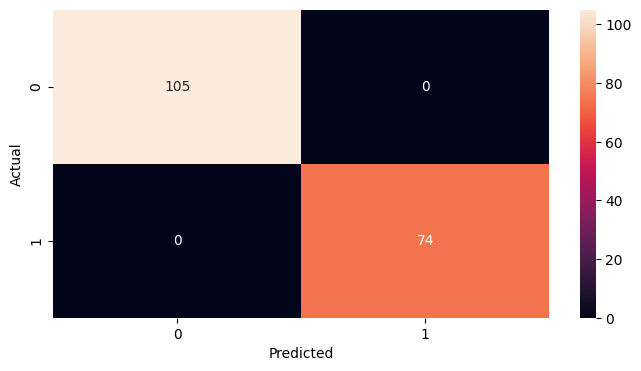

In [170]:
# plot the confusion matrix
plt.figure(figsize=(8, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [171]:
import pickle
pickle.dump(model, open('logistic_model.pkl', 'wb'))

In [177]:
df= sns.load_dataset('iris')
# df.head()

In [180]:
X = df.drop('species', axis=1)
y = df['species']

In [181]:
# train test split the data
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
model = KNeighborsClassifier(n_neighbors=11)
# fit the model on the training data
model.fit(X_train, y_train)
# predict the species for the test data
y_pred =model.predict(X_test)

In [184]:
print('Accuracy: ', accuracy_score(y_test, y_pred))
print('recall_score: ', recall_score(y_test, y_pred, average='weighted'))
print ('precision_score: ', precision_score(y_test, y_pred, average='weighted'))
print ('f1_score: ', f1_score(y_test, y_pred, average='weighted'))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

Accuracy:  1.0
recall_score:  1.0
precision_score:  1.0
f1_score:  1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [187]:
df = sns.load_dataset('tips')
X= df.drop('tip', axis=1)
y = df['tip']

In [192]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2,
random_state=42)
model = KNeighborsRegressor (n_neighbors=5, metric='minkowski', p=2)
# fit the model on the training data
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True).reindex(columns=X_train.columns, fill_value=0)
model.fit(X_train, y_train)
# predict the species for the test data
y_pred = model.predict(X_test)
print ('mean_squared_error: ', mean_squared_error(y_test, y_pred))
print ('mean_absolute_error: ', mean_absolute_error(y_test, y_pred))
print ('r2_score: ', r2_score(y_test, y_pred))
print ('MAPE: ', mean_absolute_percentage_error(y_test, y_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, y_pred)))

mean_squared_error:  0.8651555102040817
mean_absolute_error:  0.7051020408163264
r2_score:  0.3078597253641333
MAPE:  0.30199150903999467
RMSE:  0.9301373609333633


In [193]:
X_test.head()

,total_bill,size,sex_Female,smoker_No,day_Fri,day_Sat,day_Sun,time_Dinner
24,19.82,2,False,True,False,True,False,True
6,8.77,2,False,True,False,False,True,True
153,24.55,4,False,True,False,False,True,True
211,25.89,4,False,False,False,True,False,True
198,13.00,2,True,False,False,False,False,False


In [197]:
# Create input data in the same format as X_test
input_data = pd.DataFrame({
    'total_bill': [45],
    'size': [2],
    'sex': ['Male'],
    'smoker': ['No'],
    'day': ['Sun'],
    'time': ['Dinner']
})
# Apply the same transformations as X_test
input_data = pd.get_dummies(input_data, drop_first=True).reindex(columns=X_test.columns, fill_value=0)
# Make prediction
model.predict(input_data)

array([4.946])

In [204]:
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
df = sns.load_dataset('iris')
X = df.drop('species', axis=1)
y = df['species']
model = SVC(kernel='rbf')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
model.fit(X_train, y_train_encoded)
y_pred = model.predict(X_test)
# use encoded numeric labels for metric calculations to avoid string->float conversion error
y_test = y_test_encoded
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
# print (classification_report())

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
import math
import numpy as np

In [19]:
A = 20
B= 60
total = A + B
p_A = A / total
p_B = B / total
entropy = -(p_A * math.log2(p_A) + p_B * math.log2(p_B))
print('Entropy: ', entropy)
Gini = 1 - (p_A ** 2 + p_B ** 2)
print('Gini: ', Gini)

Entropy:  0.8112781244591328
Gini:  0.375


In [20]:
# Information Gain
# Assuming a split on some feature divides the dataset into two subsets
# Subset 1: 2 elements of A, 3 of B
# Subset 2: 2 elements of A, 3 of B
# Entropy and size for each subset
n_1_A, n_1_B = 2, 3
n_2_A, n_2_B = 2, 3
p_1_A = n_1_A / (n_1_A + n_1_B)
p_1_B = n_1_B / (n_1_A + n_1_B)
entropy_1 = -p_1_A * math.log2(p_1_A) - p_1_B* math.log2(p_1_B) if p_1_A and p_1_B else 0
p_2_A = n_2_A / (n_2_A + n_2_B)
p_2_B = n_2_B / (n_2_A + n_2_B)
entropy_2 = -p_2_A * math.log2(p_2_A) - p_2_B * math.log2(p_2_B) if p_2_A and p_2_B else 0
# Calculating information gain
info_gain = entropy - ((n_1_A + n_1_B) / total * entropy_1 + (n_2_A + n_2_B) / total * entropy_2)

In [21]:
info_gain = entropy - (((n_1_A + n_1_B) / total) * entropy_1 + ((n_2_A + n_2_B) / total) * entropy_2)
print(info_gain)

0.6899093001522992


In [25]:
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [24]:
df = sns.load_dataset('titanic')
X = df.drop(['survived', 'alive'], axis=1)
y = df['survived']

In [38]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

model = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True).reindex(columns=X_train.columns, fill_value=0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[92 13]
 [21 53]]
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [40]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, r2_score

model = DecisionTreeRegressor(random_state=42, max_depth=3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True).reindex(columns=X_train.columns, fill_value=0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 0.1413405283465293
R^2 Score: 0.41715677364850123
